<a href="https://colab.research.google.com/github/kotha-suganya/Computer-Vision/blob/main/COMUTER_VISION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**COMPUTER** **VISION**

IMAGE CLASSIFICATION USING PRE TRAINED MODEL

In [ ]:
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
import numpy as np

model=MobileNetV2(weights='imagenet')
img_path='/content/dog.webp'
img=image.load_img(img_path,target_size=(224,224))
x=image.img_to_array(img)
x=np.expand_dims(x, axis=0)
x=preprocess_input(x)
preds = model.predict(x)
print("Prediction:", decode_predictions(preds, top=3)[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Prediction: [('n02099712', 'Labrador_retriever', np.float32(0.36062032)), ('n02100735', 'English_setter', np.float32(0.12552829)), ('n02091831', 'Saluki', np.float32(0.07637692))]


IMAGE CARTOONNER


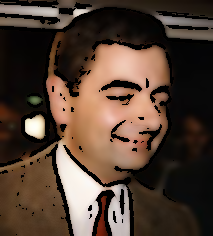

In [ ]:
import cv2
from google.colab.patches import cv2_imshow

img = cv2.imread("/content/bean.jpeg")

# Convert to gray
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Blur
gray_blur = cv2.medianBlur(gray, 5)

# Edge detection
edges = cv2.adaptiveThreshold(gray_blur, 255,
                              cv2.ADAPTIVE_THRESH_MEAN_C,
                              cv2.THRESH_BINARY, 9, 9)

# Cartoon effect
color = cv2.bilateralFilter(img, 9, 250, 250)
cartoon = cv2.bitwise_and(color, color, mask=edges)

cv2_imshow(cartoon)
cv2.waitKey(0)
cv2.destroyAllWindows()

NUMBER PLATE DETECTION

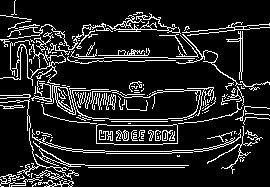

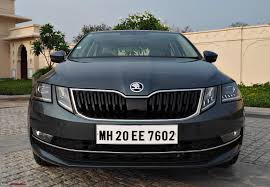

In [ ]:
import cv2
from google.colab.patches import cv2_imshow

img = cv2.imread("car.jpeg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Reduce noise
gray = cv2.bilateralFilter(gray, 11, 17, 17)

# Edge detection
edges = cv2.Canny(gray, 30, 200)

# Find contours
contours, _ = cv2.findContours(edges, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

contours = sorted(contours, key=cv2.contourArea, reverse=True)[:10]

plate = None

for cnt in contours:
    approx = cv2.approxPolyDP(cnt, 0.018 * cv2.arcLength(cnt, True), True)

    if len(approx) == 4:
        x, y, w, h = cv2.boundingRect(cnt)
        plate = img[y:y+h, x:x+w]
        cv2_imshow(plate)
        break

cv2_imshow(edges)
cv2_imshow(img)

cv2.waitKey(0)
cv2.destroyAllWindows()

FACE MASK DETECTION

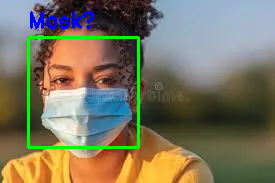

In [ ]:
import cv2
from google.colab.patches import cv2_imshow

face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

img = cv2.imread("mask.webp")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(gray, 1.3, 5)

for (x,y,w,h) in faces:
    cv2.rectangle(img, (x,y), (x+w,y+h), (0,255,0), 2)
    cv2.putText(img, "Mask?", (x, y-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,0,0), 2)

cv2_imshow(img) # Replaced cv2.imshow with cv2_imshow
cv2.waitKey(0)
cv2.destroyAllWindows()

COLOR CHANNEL SEPARATION (RGB SPLIT)

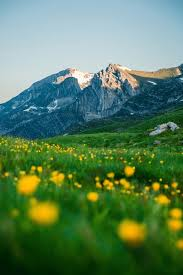

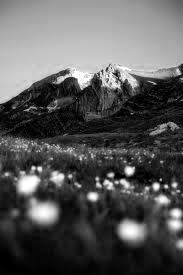

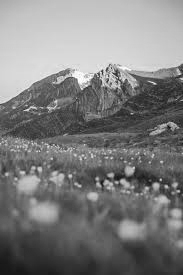

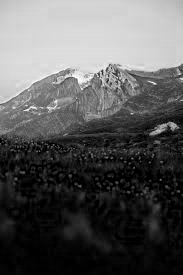

In [ ]:
import cv2
from google.colab.patches import cv2_imshow

# Upload image first
from google.colab import files
uploaded = files.upload()

# Read image
img = cv2.imread("nature.jpeg")

# Split channels
B, G, R = cv2.split(img)

# Show outputs
cv2_imshow(img)
cv2_imshow(R)
cv2_imshow(G)
cv2_imshow(B)